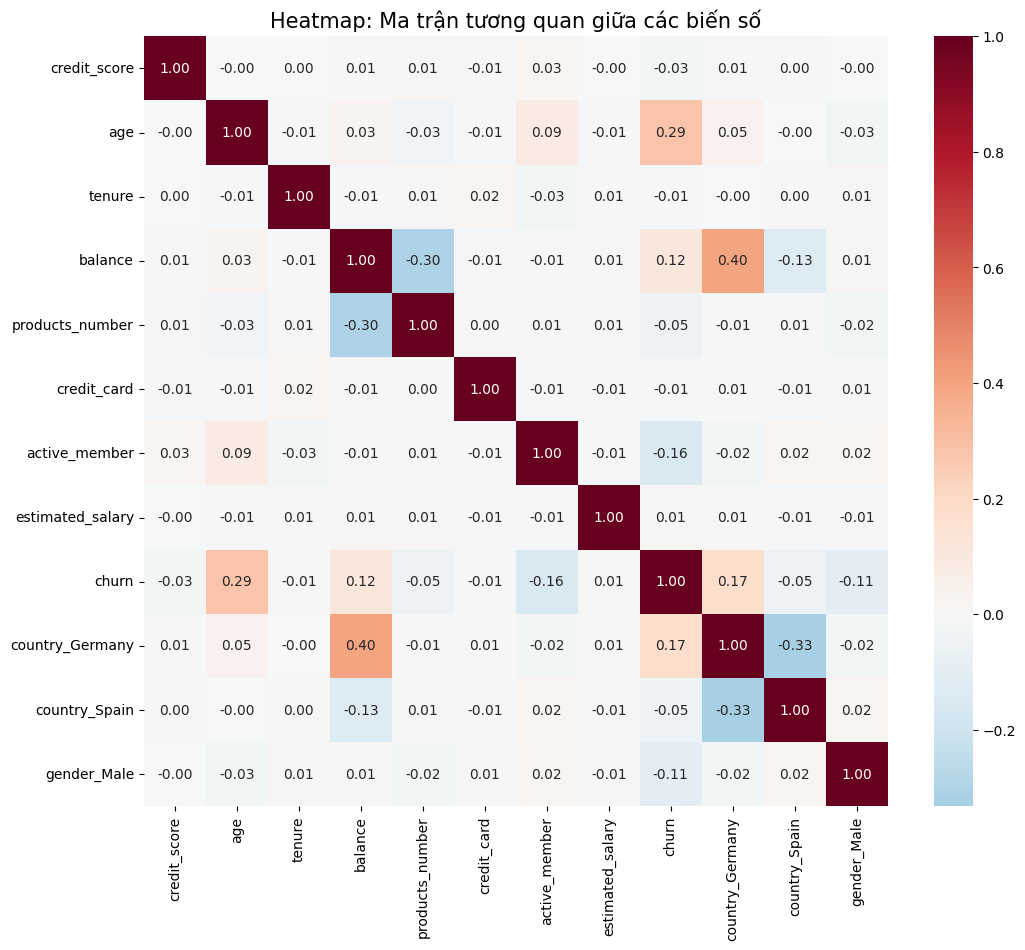

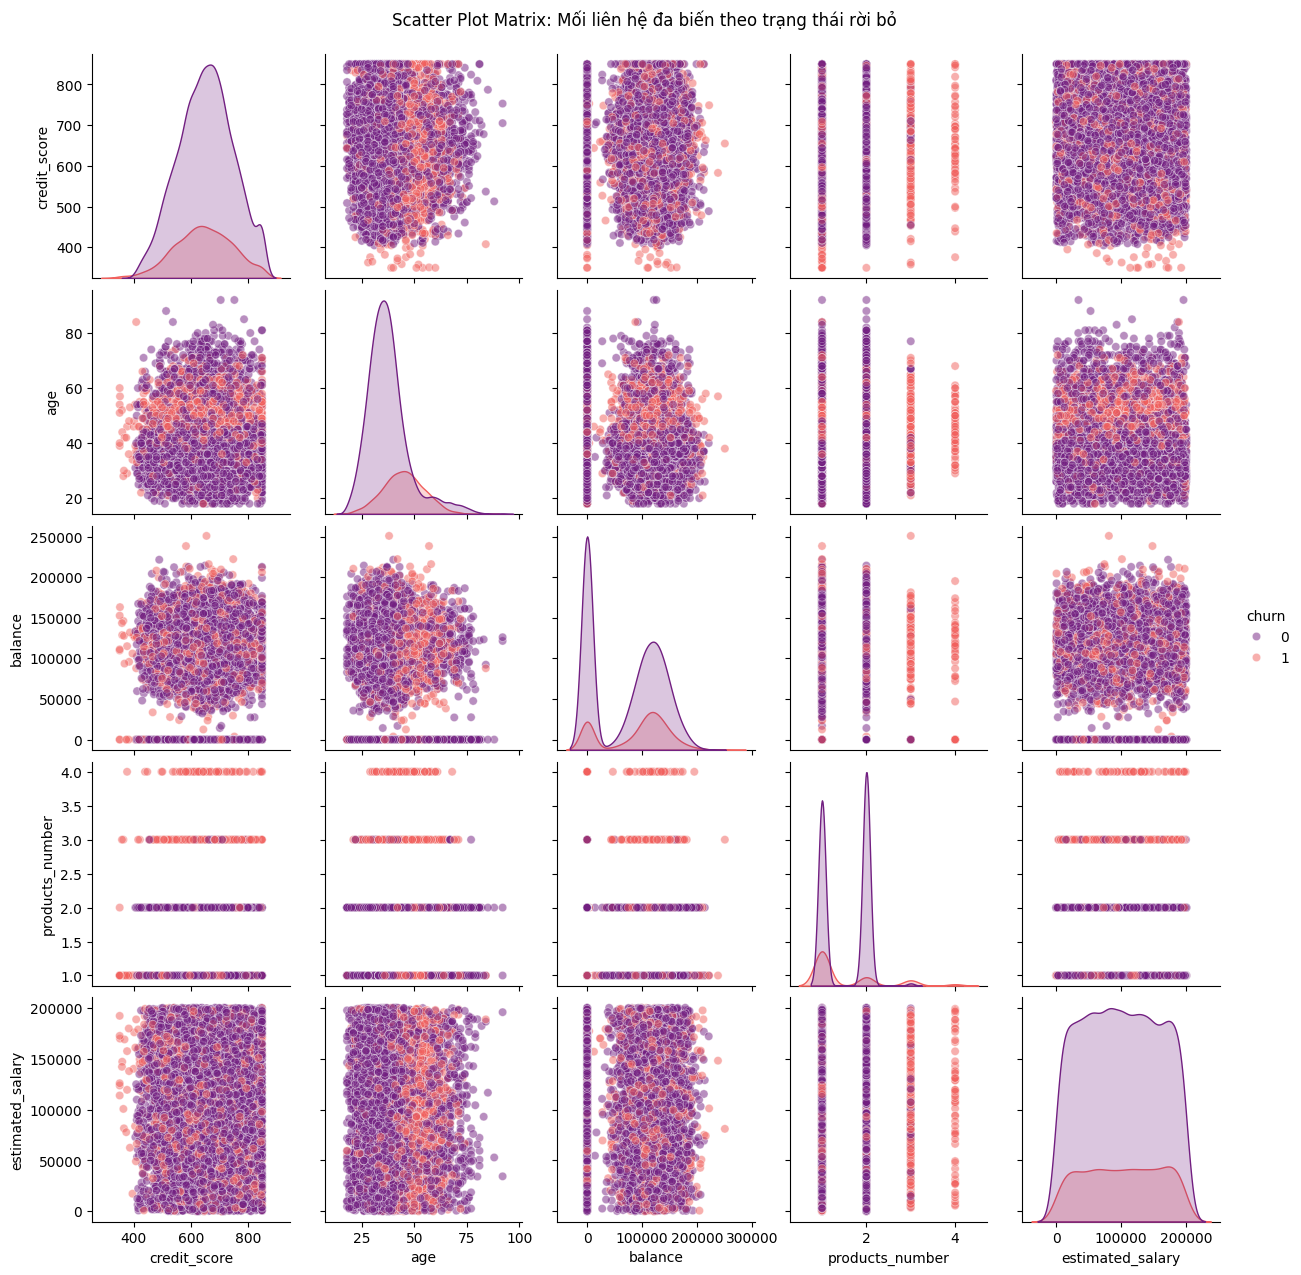

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Đọc dữ liệu
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# Bước 1: Tiền xử lý dữ liệu cho Heatmap
# Loại bỏ cột ID vì không có ý nghĩa thống kê
df_analysis = df.drop(columns=['customer_id'])

# Chuyển đổi các biến định danh (Gender, Country) thành số để tính tương quan
df_encoded = pd.get_dummies(df_analysis, columns=['country', 'gender'], drop_first=True)

# --- 2. VẼ HEATMAP TƯƠNG QUAN ---
plt.figure(figsize=(12, 10))
correlation_matrix = df_encoded.corr()

# Vẽ biểu đồ nhiệt với chú thích số
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt=".2f", center=0)
plt.title('Heatmap: Ma trận tương quan giữa các biến số', fontsize=15)
plt.show()

# --- 3. VẼ SCATTER PLOT MATRIX (PAIRPLOT) ---
# Để biểu đồ không bị rối, ta chọn các biến định lượng quan trọng nhất
important_cols = ['credit_score', 'age', 'balance', 'products_number', 'estimated_salary', 'churn']

# Vẽ ma trận tán xạ, phân loại màu theo biến Churn
sns.pairplot(df[important_cols], hue='churn', palette='magma', diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Scatter Plot Matrix: Mối liên hệ đa biến theo trạng thái rời bỏ', y=1.02)
plt.show()